In [15]:
import json
import pandas as pd
import re

def standardize_risk(risk_val):
    if not isinstance(risk_val, str):
        return risk_val
    
    # Remove common text wrappers from domain_shot results
    risk_val = risk_val.replace("Final Risk: ", "").replace("Final Risk → ", "").strip()
    
    # Handle long explanation text - extract risk keyword
    if len(risk_val) > 100:
        upper = risk_val.upper()
        if 'HIGH' in upper:
            return 'High'
        elif 'MED' in upper or 'MODERATE' in upper:
            return 'Medium'
        elif 'LOW' in upper:
            return 'Low'
        # If no clear risk keyword found in long text, return NA
        return pd.NA
    
    # Handle standard risk values
    risk_upper = risk_val.upper()
    if 'HIGH' in risk_upper:
        return 'High'
    elif 'MED' in risk_upper or 'MODERATE' in risk_upper:
        return 'Medium'
    elif 'LOW' in risk_upper:
        return 'Low'
    elif 'NOT APPLICABLE' in risk_upper or 'NOT APPLICABLE' in risk_upper:
        return 'Not Applicable'
    
    # Return as-is if no standard format found
    return risk_val

In [16]:
with open('../results_batch_1.json', 'r') as f:
    batch_1 = json.load(f)

data_1 = []
for paper_no, domains in batch_1.items():
    for domain, content in domains.items():
        if domain == 'overall':
            continue
        # Handle the nested 'result' key for domains and the direct string for 'overall'
        result = content['result'] if isinstance(content, dict) else content
        data_1.append({'Paper no.': paper_no, 'Bias domain': domain, 'result': result})

df_1 = pd.DataFrame(data_1)
df_1['result'] = df_1['result'].apply(standardize_risk)
df_1 = df_1.sort_values(by=['Paper no.', 'Bias domain'], key=lambda col: pd.to_numeric(col, errors='coerce')).reset_index(drop=True)
display(df_1[['Paper no.', 'Bias domain', 'result']].head())

,Paper no.,Bias domain,result
0,1,1,High
1,1,2,High
2,1,3,Not Applicable
3,1,4,High
4,1,5,Medium


In [17]:
with open('../results_batch_2.json', 'r') as f:
    batch_2 = json.load(f)

data_2 = []
for paper_no, domains in batch_2.items():
    for domain, content in domains.items():
        if domain == 'overall':
            continue
        result = content['result'] if isinstance(content, dict) else content
        data_2.append({'Paper no.': paper_no, 'Bias domain': domain, 'result': result})

df_2 = pd.DataFrame(data_2)
df_2['result'] = df_2['result'].apply(standardize_risk)
df_2 = df_2.sort_values(by=['Paper no.', 'Bias domain'], key=lambda col: pd.to_numeric(col, errors='coerce')).reset_index(drop=True)
display(df_2[['Paper no.', 'Bias domain', 'result']].head())

,Paper no.,Bias domain,result
0,1,1,High
1,1,2,High
2,1,3,Not Applicable
3,1,4,High
4,1,5,Medium


In [18]:
df_expert_wide = pd.read_csv('../data/sample_papers/sample_papers_expert_ratings_wide.csv')

# Drop any empty/unnamed columns (the CSV has trailing commas)
df_expert_wide = df_expert_wide.dropna(axis=1, how='all')

df_expert = pd.melt(
    df_expert_wide, 
    id_vars=['Paper no.'], 
    var_name='Bias domain', 
    value_name='result'
)

# Clean up the 'Bias domain' column to match previous tables (just the number) and standardize types
df_expert['Bias domain'] = df_expert['Bias domain'].str.replace('Bias Domain ', '')
df_expert['result'] = df_expert['result'].apply(standardize_risk)
df_expert['Paper no.'] = df_expert['Paper no.'].astype(str)

df_expert = df_expert.sort_values(by=['Paper no.', 'Bias domain'], key=lambda col: pd.to_numeric(col, errors='coerce')).reset_index(drop=True)
display(df_expert[['Paper no.', 'Bias domain', 'result']].head(10))

,Paper no.,Bias domain,result
0,1,1,High
1,1,2,Low
2,1,3,Low
3,1,4,Not Applicable
4,1,5,Medium
5,1,6,Low
6,1,7,Medium
7,2,1,Low
8,2,2,Low
9,2,3,Not Applicable


In [19]:
with open('../domain_shot_results_batch_1.json', 'r') as f:
    domain_shot_data = json.load(f)

data_domain = []
for paper_key, domains in domain_shot_data.items():
    paper_no = paper_key.replace('.md', '')
    for domain_key, content in domains.items():
        if domain_key == 'overall':
            continue
        if domain_key.startswith('domain_'):
            domain = domain_key.replace('domain_', '')
            result = pd.NA
            if isinstance(content, dict):
                parsed = content.get('parsed_response', {})
                if 'final_risk' in content:
                    result = content['final_risk']
                elif 'final_risk' in parsed:
                    result = parsed['final_risk']
                elif isinstance(parsed.get('decision_path'), list) and len(parsed['decision_path']) > 0:
                    result = parsed['decision_path'][-1]
            data_domain.append({'Paper no.': paper_no, 'Bias domain': domain, 'result': result})

df_domain = pd.DataFrame(data_domain)
df_domain['result'] = df_domain['result'].apply(standardize_risk)
df_domain = df_domain.sort_values(by=['Paper no.', 'Bias domain'], key=lambda col: pd.to_numeric(col, errors='coerce')).reset_index(drop=True)

display(df_domain[['Paper no.', 'Bias domain', 'result']].head(15))

,Paper no.,Bias domain,result
0,1,1,High
1,1,2,High
2,1,3,High
3,1,4,NaN
4,1,5,NaN
5,1,6,Medium
6,1,7,Low
7,2,1,Medium
8,2,2,High
9,2,3,Medium


In [20]:
df_1_r = df_1[df_1['Bias domain'] != 'overall'].rename(columns={'result': 'Result_Batch_1'})
df_2_r = df_2[df_2['Bias domain'] != 'overall'].rename(columns={'result': 'Result_Batch_2'})
df_expert_r = df_expert[df_expert['Bias domain'] != 'overall'].rename(columns={'result': 'Result_Expert'})
df_domain_r = df_domain[df_domain['Bias domain'] != 'overall'].rename(columns={'result': 'Result_Domain_Shot'})

df_wide = pd.merge(df_expert_r, df_1_r, on=['Paper no.', 'Bias domain'], how='outer')
df_wide = pd.merge(df_wide, df_2_r, on=['Paper no.', 'Bias domain'], how='outer')
df_wide = pd.merge(df_wide, df_domain_r, on=['Paper no.', 'Bias domain'], how='outer')

df_wide = df_wide.sort_values(by=['Paper no.', 'Bias domain'], key=lambda col: pd.to_numeric(col, errors='coerce')).reset_index(drop=True)
with pd.option_context('display.max_rows', None):
    display(df_wide)

,Paper no.,Bias domain,Result_Expert,Result_Batch_1,Result_Batch_2,Result_Domain_Shot
0,1,1,High,High,High,High
1,1,2,Low,High,High,High
2,1,3,Low,Not Applicable,Not Applicable,High
3,1,4,Not Applicable,High,High,NaN
4,1,5,Medium,Medium,Medium,NaN
5,1,6,Low,High,Medium,Medium
6,1,7,Medium,High,High,Low
7,2,1,Low,High,High,Medium
8,2,2,Low,Medium,Medium,High
9,2,3,Not Applicable,Not Applicable,Not Applicable,Medium


In [21]:
from sklearn.metrics import cohen_kappa_score

# Merge LLM and expert dataframes to align them exactly for comparison
merged_1 = pd.merge(df_1, df_expert, on=['Paper no.', 'Bias domain'], suffixes=('_llm', '_expert'))
merged_2 = pd.merge(df_2, df_expert, on=['Paper no.', 'Bias domain'], suffixes=('_llm', '_expert'))
merged_1_2 = pd.merge(df_1, df_2, on=['Paper no.', 'Bias domain'], suffixes=('_1', '_2'))
merged_domain = pd.merge(df_domain, df_expert, on=['Paper no.', 'Bias domain'], suffixes=('_domain', '_expert'))

def print_agreement(df_merged, col1, col2, comparison_name):
    df_clean = df_merged.dropna(subset=[col1, col2])
    pct_agree = (df_clean[col1] == df_clean[col2]).mean() * 100
    kappa = cohen_kappa_score(df_clean[col1].astype(str), df_clean[col2].astype(str))
    print(f"{comparison_name}:")
    print(f"  Percentage Agreement: {pct_agree:.2f}%")
    print(f"  Cohen's Kappa:        {kappa:.4f}\n")

print_agreement(merged_1, 'result_llm', 'result_expert', "Batch 1 vs Expert")
print_agreement(merged_2, 'result_llm', 'result_expert', "Batch 2 vs Expert")
print_agreement(merged_1_2, 'result_1', 'result_2', "Batch 1 vs Batch 2")
print_agreement(merged_domain, 'result_domain', 'result_expert', "Domain Shot vs Expert")

Batch 1 vs Expert:
  Percentage Agreement: 45.71%
  Cohen's Kappa:        0.3048

Batch 2 vs Expert:
  Percentage Agreement: 45.71%
  Cohen's Kappa:        0.2941

Batch 1 vs Batch 2:
  Percentage Agreement: 84.29%
  Cohen's Kappa:        0.7532

Domain Shot vs Expert:
  Percentage Agreement: 25.00%
  Cohen's Kappa:        -0.0783



In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Overall agreement: % matches (including both NaN = match)
def agree_pct(col1, col2):
    matches = ((col1 == col2) | (col1.isna() & col2.isna())).sum()
    return (matches / len(col1)) * 100

b2_agree = agree_pct(df_wide['Result_Expert'], df_wide['Result_Batch_2'])
ds_agree = agree_pct(df_wide['Result_Expert'], df_wide['Result_Domain_Shot'])

print("OVERALL AGREEMENT")
print(f"Batch_2:      {b2_agree:.1f}%")
print(f"Domain_Shot:  {ds_agree:.1f}%")
print(f"Difference:   {b2_agree - ds_agree:+.1f}%")
print(f"\nMissing data: Expert={df_wide['Result_Expert'].isna().sum()}, "
      f"B2={df_wide['Result_Batch_2'].isna().sum()}, "
      f"DS={df_wide['Result_Domain_Shot'].isna().sum()}")

OVERALL AGREEMENT
Batch_2:      45.7%
Domain_Shot:  22.9%
Difference:   +22.9%

Missing data: Expert=0, B2=0, DS=6


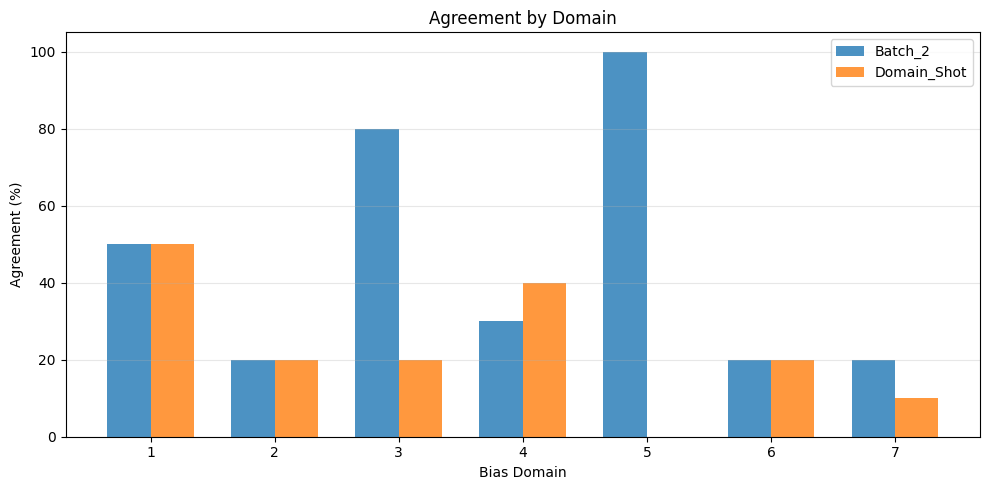

Agreement % by Domain:
  Domain 1: B2=50% | DS=50%
  Domain 2: B2=20% | DS=20%
  Domain 3: B2=80% | DS=20%
  Domain 4: B2=30% | DS=40%
  Domain 5: B2=100% | DS=0%
  Domain 6: B2=20% | DS=20%
  Domain 7: B2=20% | DS=10%


In [23]:
# Agreement by domain (bar chart)
domains = sorted([int(d) for d in df_wide['Bias domain'].unique()])
b2_by_domain = []
ds_by_domain = []

for domain in domains:
    mask = df_wide['Bias domain'] == str(domain)
    b2_by_domain.append(agree_pct(df_wide.loc[mask, 'Result_Expert'], 
                                   df_wide.loc[mask, 'Result_Batch_2']))
    ds_by_domain.append(agree_pct(df_wide.loc[mask, 'Result_Expert'], 
                                   df_wide.loc[mask, 'Result_Domain_Shot']))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(domains))
width = 0.35
ax.bar(x - width/2, b2_by_domain, width, label='Batch_2', alpha=0.8)
ax.bar(x + width/2, ds_by_domain, width, label='Domain_Shot', alpha=0.8)
ax.set_xlabel('Bias Domain')
ax.set_ylabel('Agreement (%)')
ax.set_title('Agreement by Domain')
ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Agreement % by Domain:")
for i, d in enumerate(domains):
    print(f"  Domain {d}: B2={b2_by_domain[i]:.0f}% | DS={ds_by_domain[i]:.0f}%")

In [24]:
# Overestimate vs Underestimate by domain
def count_bias(col1, col2):
    mask = col1.notna() & col2.notna()
    over = ((col1[mask] == 'High') & (col2[mask].isin(['Low', 'Medium']))).sum()
    under = ((col1[mask].isin(['Low', 'Medium'])) & (col2[mask] == 'High')).sum()
    return over, under

summary = []
for domain in domains:
    mask = df_wide['Bias domain'] == str(domain)
    exp = df_wide.loc[mask, 'Result_Expert']
    b2 = df_wide.loc[mask, 'Result_Batch_2']
    ds = df_wide.loc[mask, 'Result_Domain_Shot']
    
    b2_over, b2_under = count_bias(b2, exp)
    ds_over, ds_under = count_bias(ds, exp)
    
    summary.append({
        'Domain': domain,
        'B2_Over': b2_over, 'B2_Under': b2_under,
        'DS_Over': ds_over, 'DS_Under': ds_under
    })

df_summary = pd.DataFrame(summary)
print("\nOverestimate/Underestimate Counts:")
print(df_summary.to_string(index=False))
print("\n(Over = LLM says High when Expert says Low/Medium)")
print("(Under = LLM says Low/Medium when Expert says High)")


Overestimate/Underestimate Counts:
 Domain  B2_Over  B2_Under  DS_Over  DS_Under
      1        4         1        1         1
      2        2         0        6         0
      3        0         0        1         0
      4        3         0        1         1
      5        0         0        1         0
      6        2         2        0         3
      7        8         0        3         0

(Over = LLM says High when Expert says Low/Medium)
(Under = LLM says Low/Medium when Expert says High)


In [25]:
# How well do LLMs classify each risk level?
risk_levels = sorted([x for x in df_wide['Result_Expert'].unique() if pd.notna(x)])

print("\nAccuracy by Risk Level (Expert says):")
for risk in risk_levels:
    mask = df_wide['Result_Expert'] == risk
    b2_match = ((df_wide.loc[mask, 'Result_Expert'] == df_wide.loc[mask, 'Result_Batch_2']) | 
                (df_wide.loc[mask, 'Result_Expert'].isna() & df_wide.loc[mask, 'Result_Batch_2'].isna())).sum()
    ds_match = ((df_wide.loc[mask, 'Result_Expert'] == df_wide.loc[mask, 'Result_Domain_Shot']) | 
                (df_wide.loc[mask, 'Result_Expert'].isna() & df_wide.loc[mask, 'Result_Domain_Shot'].isna())).sum()
    total = mask.sum()
    print(f"  {risk:15} n={total:2d}  B2: {b2_match}/{total} ({100*b2_match/total:.0f}%)  "
          f"DS: {ds_match}/{total} ({100*ds_match/total:.0f}%)")


Accuracy by Risk Level (Expert says):
  High            n=13  B2: 10/13 (77%)  DS: 8/13 (62%)
  Low             n=26  B2: 2/26 (8%)  DS: 7/26 (27%)
  Medium          n=21  B2: 12/21 (57%)  DS: 1/21 (5%)
  Not Applicable  n=10  B2: 8/10 (80%)  DS: 0/10 (0%)


In [26]:
# Which papers are hardest to assess?
papers = sorted([int(p) for p in df_wide['Paper no.'].unique()])

paper_agree = []
for paper in papers:
    mask = df_wide['Paper no.'] == str(paper)
    b2 = agree_pct(df_wide.loc[mask, 'Result_Expert'], df_wide.loc[mask, 'Result_Batch_2'])
    ds = agree_pct(df_wide.loc[mask, 'Result_Expert'], df_wide.loc[mask, 'Result_Domain_Shot'])
    avg = (b2 + ds) / 2
    paper_agree.append({'Paper': paper, 'B2%': b2, 'DS%': ds, 'Avg%': avg})

df_paper = pd.DataFrame(paper_agree).sort_values('Avg%', ascending=False).reset_index(drop=True)

print("\nPaper Difficulty Ranking (by avg agreement):")
print("Rank 1 = Easiest, Rank 10 = Hardest")
for idx, row in df_paper.iterrows():
    print(f"  Rank {idx+1:2d}: Paper {int(row['Paper']):2d}  B2={row['B2%']:5.0f}%  "
          f"DS={row['DS%']:5.0f}%  Avg={row['Avg%']:5.0f}%")


Paper Difficulty Ranking (by avg agreement):
Rank 1 = Easiest, Rank 10 = Hardest
  Rank  1: Paper  6  B2=   57%  DS=   43%  Avg=   50%
  Rank  2: Paper  3  B2=   57%  DS=   29%  Avg=   43%
  Rank  3: Paper  9  B2=   43%  DS=   29%  Avg=   36%
  Rank  4: Paper  8  B2=   43%  DS=   29%  Avg=   36%
  Rank  5: Paper  5  B2=   29%  DS=   43%  Avg=   36%
  Rank  6: Paper  7  B2=   57%  DS=   14%  Avg=   36%
  Rank  7: Paper  4  B2=   43%  DS=   14%  Avg=   29%
  Rank  8: Paper  2  B2=   43%  DS=   14%  Avg=   29%
  Rank  9: Paper 10  B2=   57%  DS=    0%  Avg=   29%
  Rank 10: Paper  1  B2=   29%  DS=   14%  Avg=   21%


In [27]:
# Confusion matrices: what misclassifications happen?
categories = ['High', 'Medium', 'Low', 'Not Applicable']

def confusion_matrix(expert, llm):
    mask = expert.notna() & llm.notna()
    matrix = pd.DataFrame(0, index=categories, columns=categories)
    for e, l in zip(expert[mask], llm[mask]):
        if e in categories and l in categories:
            matrix.loc[l, e] += 1
    return matrix

cm_b2 = confusion_matrix(df_wide['Result_Expert'], df_wide['Result_Batch_2'])
cm_ds = confusion_matrix(df_wide['Result_Expert'], df_wide['Result_Domain_Shot'])

print("\nConfusion Matrix: Batch_2 vs Expert")
print("(Rows=Batch_2 predicts, Cols=Expert says)")
print(cm_b2)
print(f"\nConfusion Matrix: Domain_Shot vs Expert")
print("(Rows=Domain_Shot predicts, Cols=Expert says)")
print(cm_ds)
print("\n(Diagonal = correct | Off-diagonal = errors)")


Confusion Matrix: Batch_2 vs Expert
(Rows=Batch_2 predicts, Cols=Expert says)
                High  Medium  Low  Not Applicable
High              10       9   10               2
Medium             1      12   12               0
Low                2       0    2               0
Not Applicable     0       0    2               8

Confusion Matrix: Domain_Shot vs Expert
(Rows=Domain_Shot predicts, Cols=Expert says)
                High  Medium  Low  Not Applicable
High               8       4    9               0
Medium             1       1    8               2
Low                4      13    7               6
Not Applicable     0       0    1               0

(Diagonal = correct | Off-diagonal = errors)


In [28]:
# Decision Node Answer Distribution# Analyze what percentage of papers answered "Yes", "No", "Seemingly Yes", etc. at each nodeimport jsonfrom collections import Counterwith open('../results_batch_2.json') as f:    batch_2 = json.load(f)# Collect all node answersnode_answers = {}node_questions = {}for paper_no, domains in batch_2.items():    for domain_id, domain_data in domains.items():        if domain_id == 'overall':            continue        if 'path' in domain_data:            for step in domain_data['path']:                node = step['node']                answer = step['answer'].lower()                question = step.get('question', '')                                if node not in node_answers:                    node_answers[node] = Counter()                    node_questions[node] = question                                node_answers[node][answer] += 1# Display results by domaindomains_to_check = [1, 2, 3, 4, 5, 6, 7]  # All domainsprint("\n" + "="*100)print("DECISION NODE ANSWER DISTRIBUTION BY DOMAIN")print("="*100)for domain in domains_to_check:    print(f"\n--- DOMAIN {domain} ---")    domain_nodes = {k: v for k, v in node_answers.items() if k.startswith(f'q_{domain}_')}        if not domain_nodes:        print(f"  No nodes found for domain {domain}")        continue        for node_id in sorted(domain_nodes.keys()):        answers = node_answers[node_id]        total = sum(answers.values())        print(f"\n  {node_id}: {node_questions[node_id][:70]}...")                # Sort by frequency descending        for answer, count in sorted(answers.items(), key=lambda x: x[1], reverse=True):            pct = (count / total) * 100            bar = '█' * int(pct / 5)            print(f"    {answer:20s}: {count:2d}/{total} ({pct:5.1f}%) {bar}")print("\n" + "="*100)print("SUMMARY: DOMAIN 2, 6, 7 show biased answer distributions (e.g., mostly 'Yes')")print("="*100)


FileNotFoundError: [Errno 2] No such file or directory: 'results_batch_2.json'